# Text Mining Project — Agentic LLM Solution (`tm_agents_12`)

**Group 12** | Market-sentiment classification: Bearish (0) / Bullish (1) / Neutral (2)

This notebook is an **extra, exploratory branch** of the project — a two-agent system built
on **Azure OpenAI (ChatGPT)**, following the conventions of **Lab 6 — Agentic AI** and the
**Orchestrator/Worker** pattern from **Lab 6b, §8**.

### The idea (what the user asked for)

```
            tweet
              |
              v
   [ CLASSIFIER  (worker) ]  ->  proposes a label, e.g. "bearish"
              |  proposed label + reason
              v
   [ VALIDATOR  (main)    ]  ->  "Is this *indeed* a bearish tweet?"
              |                   agrees, or overrides -> FINAL label
              v
          FINAL label
```

The **classifier** reads a tweet and returns a sentiment label. The **validator** (the *main*
agent) does not trust it blindly: it re-examines the tweet, asks whether the proposed label is
really correct (checking sarcasm, negation, factual-vs-directional), and either confirms or
overrides it. This is the **LLM-as-judge / Reflexion** idea expressed as a two-agent pipeline.

### Why a separate notebook
This is a generative, multi-call, non-deterministic system — very different from the frozen-encoder
probing and fine-tuning in `tm_tests_12` / `tm_final_12`. Keeping it separate leaves the submitted
pipeline clean and reproducible, while letting us report this as an improved **decoder** branch
(the old `llama3.2:3b` zero-shot scored only macro-F1 **0.446**).

### Goal of the experiment
Run the two agents over the **exact same 1,909-tweet validation split** used for our submitted model
(`train_test_split(test_size=0.20, random_state=42, stratify=y)`), then produce a full
classification report (precision, recall, F1 per class, macro-F1, accuracy, confusion matrix) and a
**side-by-side comparison**: *how much better — or worse — is the LLM than our submitted solution
(macro-F1 0.808)?*


## 0. Setup

Same stack as Lab 6 (`langchain`, `langchain-openai`, `langchain-classic`). Uncomment to install.

In [26]:
# !pip install -q langchain langchain-openai langchain-core langchain-community langchain-classic
# !pip install -q scikit-learn pandas matplotlib tqdm
! pip install -q langchain-huggingface langchain-community chromadb sentence-transformers


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## 1. Azure OpenAI connection  *(identical conventions to Lab 6)*

We reuse the exact Lab 6 setup: `AzureChatOpenAI`, `model='ChatGPT'`, the NOVA IMS playground
endpoint, `api_version='2024-02-15-preview'`, and `temperature=0` (deterministic — best for agents).

> **Key file** — point `KEY_PATH` at your `Azure Open AI Key.txt`. By default we look in the sibling
> `Lab6` folder (same key file Lab 6 used). Change it if your key lives elsewhere.

In [1]:
import os, json, re, time, hashlib
from pathlib import Path

# Reproducibility (same seed as the rest of the project)
RANDOM_STATE = 42

# Where things live
DATA_DIR  = "data/"                       # train.csv / test.csv (this project)
CACHE_DIR = "cache_agents/"               # agent predictions are cached here (resumable)
os.makedirs(CACHE_DIR, exist_ok=True)

# Azure key: same file Lab 6 used. Adjust if needed.
KEY_PATH_CANDIDATES = [
    "../Lab6/Azure Open AI Key.txt",
    "../Lab 6/Azure Open AI Key.txt",
    "Azure Open AI Key.txt",
]
KEY_PATH = next((p for p in KEY_PATH_CANDIDATES if os.path.exists(p)), KEY_PATH_CANDIDATES[0])

AZURE_ENDPOINT = "https://novaimsplayground.openai.azure.com/"
AZURE_MODEL    = "ChatGPT"
API_VERSION    = "2024-02-15-preview"
print("Key file:", KEY_PATH, "| exists:", os.path.exists(KEY_PATH))

Key file: ../Lab6/Azure Open AI Key.txt | exists: True


In [4]:
from langchain_openai import AzureChatOpenAI

with open(KEY_PATH, "r", encoding="utf-8") as f:
    key = f.read().strip()

os.environ["AZURE_OPENAI_KEY"]      = key
os.environ["AZURE_OPENAI_ENDPOINT"] = AZURE_ENDPOINT

# temperature=0 -> deterministic, exactly as in Lab 6
llm = AzureChatOpenAI(
    temperature=0,
    model=AZURE_MODEL,
    azure_endpoint=os.environ["AZURE_OPENAI_ENDPOINT"],
    openai_api_type="azure",
    api_key=os.environ["AZURE_OPENAI_KEY"],
    api_version=API_VERSION,
)
print("LLM ready:", llm.model_name)

LLM ready: ChatGPT


In [5]:
# Quick smoke test — confirms the Azure connection works before the big run.
try:
    print(llm.invoke("Reply with the single word: ready").content)
except Exception as e:
    print("Azure call failed — check key / endpoint / quota:\n", e)

ready


## 2. Data — reproduce the *exact* validation split

We rebuild the identical 80/20 stratified split used in `tm_tests_12.ipynb`
(`random_state=42`), so the LLM is scored on the **same 1,909 tweets** as our submitted model.
The labels are: **0 = Bearish, 1 = Bullish, 2 = Neutral**.

In [6]:
import pandas as pd
from sklearn.model_selection import train_test_split

LABEL_NAMES = {0: "bearish", 1: "bullish", 2: "neutral"}
NAME_TO_ID  = {v: k for k, v in LABEL_NAMES.items()}

def read_csv_safe(path):
    for enc in ["utf-8", "latin-1"]:
        try:    return pd.read_csv(path, encoding=enc)
        except UnicodeDecodeError: continue
    raise ValueError(f"Cannot decode {path}")

train_df = read_csv_safe(DATA_DIR + "train.csv")
train_df.columns = [c.strip().lower() for c in train_df.columns]

X = train_df["text"].reset_index(drop=True)
y = train_df["label"].reset_index(drop=True)

X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y)

X_val_raw = X_val_raw.reset_index(drop=True)
y_val     = y_val.reset_index(drop=True)

print(f"Validation tweets: {len(X_val_raw)}")
print("Class balance:", {LABEL_NAMES[k]: int(v) for k, v in y_val.value_counts().sort_index().items()})

c:\Users\artem\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


Validation tweets: 1909
Class balance: {'bearish': 288, 'bullish': 385, 'neutral': 1236}


## 3. The two prompts

Both agents share the same Azure model — *the only thing that makes them behave differently is
their system prompt* (exactly the lesson from Lab 6b's two-agent example). We force **JSON output**
so the results parse cleanly over thousands of calls.

In [ ]:
CLASSIFIER_SYSTEM = (
    "You are a financial-sentiment classifier for stock-market tweets. "
    "Classify the sentiment expressed toward the asset/market as exactly one of: "
    "bearish, bullish, neutral.\n"
    "- bearish = expects price to fall / negative outlook / bad news for the asset\n"
    "- bullish = expects price to rise / positive outlook / good news for the asset\n"
    "- neutral = factual, a question, mixed, or no clear directional view\n"
    'Return ONLY compact JSON: {"label": "bearish|bullish|neutral", "reason": "<=8 words"}'
)

VALIDATOR_SYSTEM = (
    "You are a senior financial-sentiment reviewer. A junior classifier has labeled a tweet. "
    "Your job is to verify whether that label is truly correct. Re-read the tweet carefully and "
    "consider: sarcasm, negation, hedging, and that purely factual statements or questions are "
    "NEUTRAL (not directional). Allowed labels: bearish, bullish, neutral.\n"
    "Return ONLY compact JSON: "
    '{"verdict": "agree|disagree", "final_label": "bearish|bullish|neutral", "why": "<=12 words"}'
)

def classify_user(tweet):
    return f'Classify this tweet:\n"""{tweet}"""'

def validate_user(tweet, proposed, reason):
    return (f'Tweet:\n"""{tweet}"""\n'
            f'Junior classifier proposed: {proposed}  (reason: {reason})\n'
            f'Is this indeed a {proposed} tweet? Confirm or correct it.')

## 4. Robust JSON parsing + the classify->validate pipeline

`safe_json` tolerates the small formatting quirks LLMs produce (code fences, stray text). Each
tweet is processed once and **cached to disk by a hash of the tweet**, so the long run is fully
**resumable** — if it stops, just re-run the eval cell and it continues where it left off.

`MAX_ROUNDS = 1` -> a single validate pass (classifier proposes, validator confirms/overrides).
Set `MAX_ROUNDS = 2` to let the validator bounce its feedback back to the classifier once
(closer to true Reflexion) at the cost of more calls.

In [ ]:
MAX_ROUNDS = 1   # 1 = single validate pass; 2 = iterate (classifier retries once on disagreement)

def safe_json(text):
    """Extract the first JSON object from an LLM reply; tolerant of code fences / extra prose."""
    if text is None:
        return {}
    text = text.strip()
    text = re.sub(r"^```(?:json)?|```$", "", text, flags=re.MULTILINE).strip()
    m = re.search(r"\{.*\}", text, flags=re.DOTALL)
    if not m:
        return {}
    try:
        return json.loads(m.group(0))
    except Exception:
        return {}

def norm_label(s):
    """Map any model output to a canonical label id 0/1/2, or None if unrecognised."""
    if s is None:
        return None
    s = str(s).strip().lower()
    for name, idx in NAME_TO_ID.items():
        if name in s:
            return idx
    if s in {"0", "1", "2"}:
        return int(s)
    return None

def _invoke(system, user, retries=4):
    """One chat call with exponential backoff for rate limits / transient errors."""
    from langchain_core.messages import SystemMessage, HumanMessage
    for attempt in range(retries):
        try:
            r = llm.invoke([SystemMessage(content=system), HumanMessage(content=user)])
            return r.content
        except Exception as e:
            if attempt == retries - 1:
                raise
            time.sleep(2 ** attempt)
    return None

def classify_validate(tweet):
    """Full two-agent decision for one tweet. Returns dict with both stages + final label id."""
    # Stage 1: classifier (worker)
    c_raw = _invoke(CLASSIFIER_SYSTEM, classify_user(tweet))
    c = safe_json(c_raw)
    proposed = (c.get("label") or "").lower()
    reason   = c.get("reason", "")

    # Stage 2: validator (main agent)
    v_raw = _invoke(VALIDATOR_SYSTEM, validate_user(tweet, proposed or "unknown", reason))
    v = safe_json(v_raw)
    verdict    = (v.get("verdict") or "").lower()
    final_name = v.get("final_label") or proposed

    # Optional Reflexion: if they disagree and MAX_ROUNDS>=2, classifier retries with feedback
    rounds = 1
    while MAX_ROUNDS >= 2 and verdict == "disagree" and rounds < MAX_ROUNDS:
        feedback = (f'A reviewer disagreed and suggested "{final_name}" because: {v.get("why","")}. '
                    f'Reconsider and classify again.\n{classify_user(tweet)}')
        c_raw = _invoke(CLASSIFIER_SYSTEM, feedback)
        c = safe_json(c_raw); proposed = (c.get("label") or "").lower(); reason = c.get("reason", "")
        v_raw = _invoke(VALIDATOR_SYSTEM, validate_user(tweet, proposed or "unknown", reason))
        v = safe_json(v_raw); verdict = (v.get("verdict") or "").lower()
        final_name = v.get("final_label") or proposed
        rounds += 1

    final_id = norm_label(final_name)
    if final_id is None:
        final_id = norm_label(proposed)
    if final_id is None:
        final_id = 2  # last resort: majority class (neutral)
    return {
        "proposed": norm_label(proposed), "verdict": verdict,
        "final": final_id, "rounds": rounds,
        "classifier_raw": c_raw, "validator_raw": v_raw,
    }

## 5. Faithful demo on a few tweets

Before the big run, a small verbose demo so you can *see* the two agents disagree/agree — the same
spirit as the Lab 6b two-agent example.

In [9]:
for i in range(6):
    t = X_val_raw[i]
    out = classify_validate(t)
    print("-" * 70)
    print("TWEET:", t[:110])
    print(f"  classifier -> {LABEL_NAMES.get(out['proposed'],'?'):8s} | "
          f"validator: {out['verdict'] or '-':8s} -> FINAL: {LABEL_NAMES[out['final']]:8s} | "
          f"truth: {LABEL_NAMES[y_val[i]]}")

----------------------------------------------------------------------
TWEET: i love it when fertility clinic's decorate ...... and it's not even Thanks Giving ..... i.e. premature https:/
  classifier -> neutral  | validator: agree    -> FINAL: neutral  | truth: neutral
----------------------------------------------------------------------
TWEET: IRS investigators scrutinize Bitcoin ATMs and kiosks
  classifier -> neutral  | validator: agree    -> FINAL: neutral  | truth: neutral
----------------------------------------------------------------------
TWEET: $SRPT higher by 4.5% today clearing 21 MA and nearing Feb OpEx value range breakout
  classifier -> bullish  | validator: agree    -> FINAL: bullish  | truth: bullish
----------------------------------------------------------------------
TWEET: Wells Fargo Downgrades Netflix On Spending Concerns
  classifier -> bearish  | validator: agree    -> FINAL: bearish  | truth: bearish
--------------------------------------------------------

## 6. Full validation run  *(all 1,909 tweets)*

Cached and resumable. With `MAX_ROUNDS=1` this is ~2 Azure calls per tweet (~3.8k calls); expect it
to take a while and depend on your Azure rate limit. Re-running this cell after an interruption
**resumes** from the cache.

In [10]:
from tqdm.auto import tqdm

CACHE_FILE = os.path.join(CACHE_DIR, f"val_preds_rounds{MAX_ROUNDS}.json")

results = {}
if os.path.exists(CACHE_FILE):
    with open(CACHE_FILE, "r", encoding="utf-8") as f:
        results = json.load(f)
    print(f"Resuming — {len(results)} tweets already done.")

def key_for(idx, tweet):
    h = hashlib.md5(tweet.encode("utf-8")).hexdigest()[:10]
    return f"{idx}_{h}"

SAVE_EVERY = 25
for idx in tqdm(range(len(X_val_raw)), desc="classify+validate"):
    t = X_val_raw[idx]
    k = key_for(idx, t)
    if k in results:
        continue
    try:
        out = classify_validate(t)
    except Exception as e:
        out = {"proposed": None, "verdict": "error", "final": 2, "rounds": 0, "error": str(e)}
    out["truth"] = int(y_val[idx])
    results[k] = out
    if len(results) % SAVE_EVERY == 0:
        with open(CACHE_FILE, "w", encoding="utf-8") as f:
            json.dump(results, f)

with open(CACHE_FILE, "w", encoding="utf-8") as f:
    json.dump(results, f)
print("Done:", len(results), "tweets. Cache:", CACHE_FILE)

classify+validate:   0%|          | 0/1909 [00:00<?, ?it/s]

Done: 1909 tweets. Cache: cache_agents/val_preds_rounds1.json


## 7. Full classification report

Precision, recall, F1 per class, **macro-F1**, accuracy, and a confusion matrix — computed on the
same validation set as our submitted model.

In [11]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score

ordered = sorted(results.items(), key=lambda kv: int(kv[0].split("_")[0]))
y_true = np.array([v["truth"] for _, v in ordered])
y_pred = np.array([v["final"] for _, v in ordered])

target_names = ["bearish(0)", "bullish(1)", "neutral(2)"]
print(classification_report(y_true, y_pred, target_names=target_names, digits=3))

macro = f1_score(y_true, y_pred, average="macro")
acc   = accuracy_score(y_true, y_pred)
print(f"\nMacro-F1 : {macro:.3f}")
print(f"Accuracy : {acc:.3f}")
print(f"(rounds setting MAX_ROUNDS={MAX_ROUNDS}; n={len(y_true)})")

              precision    recall  f1-score   support

  bearish(0)      0.663     0.840     0.741       288
  bullish(1)      0.667     0.891     0.763       385
  neutral(2)      0.923     0.769     0.839      1236

    accuracy                          0.805      1909
   macro avg      0.751     0.834     0.781      1909
weighted avg      0.832     0.805     0.809      1909


Macro-F1 : 0.781
Accuracy : 0.805
(rounds setting MAX_ROUNDS=1; n=1909)


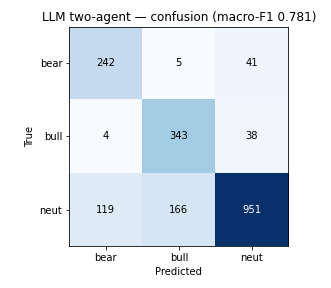

In [ ]:
import matplotlib.pyplot as plt
cm = confusion_matrix(y_true, y_pred, labels=[0, 1, 2])
fig, ax = plt.subplots(figsize=(4.6, 4.0))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(3)); ax.set_yticks(range(3))
ax.set_xticklabels(["bear", "bull", "neut"]); ax.set_yticklabels(["bear", "bull", "neut"])
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
ax.set_title(f"LLM two-agent — confusion (macro-F1 {macro:.3f})")
for i in range(3):
    for j in range(3):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black")
plt.tight_layout(); plt.show()

## 8. Comparison vs our submitted solution

The numbers below for the **submitted** model and the **old decoder baseline** come from
`tm_tests_12` (same validation split). The LLM row is filled in from the run above. This is the
table to drop into the report's decoder/LLM section.

In [ ]:
baseline_rows = [
    ("Concat FinBERT+twitter-roberta -> MLP (SUBMITTED)", 0.808, 0.859),
    ("Fine-tuned DistilBERT (extra)",                     0.811, 0.853),
    ("twitter-roberta (frozen) -> MLP",                   0.784, None),
    ("Decoder — llama3.2:3b zero-shot (old)",             0.446, None),
    ("Majority-class baseline",                           0.262, 0.647),
]

llm_row = (f"LLM two-agent classify+validate (Azure ChatGPT, rounds={MAX_ROUNDS})", macro, acc)

print(f"{'Model':54s}  {'Macro-F1':>9s}  {'Accuracy':>9s}")
print("-" * 80)
for name, mf, ac in baseline_rows + [llm_row]:
    star = "  <<< THIS NOTEBOOK" if name.startswith('LLM two-agent') else ""
    ac_s = ('%.3f' % ac) if ac is not None else '   -   '
    print(f"{name:54s}  {mf:9.3f}  {ac_s:>9s}{star}")

delta = macro - 0.808
verdict = "BETTER than" if delta > 0 else "worse than" if delta < 0 else "tied with"
print(f"\nThe LLM two-agent system is {verdict} our submitted model "
      f"by {delta:+.3f} macro-F1.")

Model                                                    Macro-F1   Accuracy
--------------------------------------------------------------------------------
Concat FinBERT+twitter-roberta -> MLP (SUBMITTED)           0.808      0.859
Fine-tuned DistilBERT (extra)                               0.811      0.853
twitter-roberta (frozen) -> MLP                             0.784       -   
Decoder — llama3.2:3b zero-shot (old)                       0.446       -   
Majority-class baseline                                     0.262      0.647
LLM two-agent classify+validate (Azure ChatGPT, rounds=1)      0.781      0.805  <<< THIS NOTEBOOK

The LLM two-agent system is worse than our submitted model by -0.027 macro-F1.


## 9. Where the validator changed the classifier's mind

A quick look at how often the validator overrode the classifier, and whether those overrides helped
— useful narrative for the report (does the second agent actually add value?).

In [ ]:
changed = corrected = broke = 0
examples = []
for _, v in ordered:
    p, f, t = v.get("proposed"), v["final"], v["truth"]
    if p is None:
        continue
    if p != f:
        changed += 1
        if f == t and p != t:  corrected += 1
        if p == t and f != t:  broke += 1
        if len(examples) < 8:
            examples.append((LABEL_NAMES.get(p, '?'), LABEL_NAMES[f], LABEL_NAMES[t]))

print(f"Validator overrode the classifier on {changed} tweets.")
print(f"  helped (fixed a wrong label): {corrected}")
print(f"  hurt  (broke a right label) : {broke}")
print("\nSample overrides (classifier -> final | truth):")
for p, f, t in examples:
    print(f"  {p:8s} -> {f:8s} | truth {t}")

Validator overrode the classifier on 66 tweets.
  helped (fixed a wrong label): 44
  hurt  (broke a right label) : 19

Sample overrides (classifier -> final | truth):
  bullish  -> neutral  | truth neutral
  bullish  -> neutral  | truth neutral
  bearish  -> neutral  | truth neutral
  bullish  -> neutral  | truth neutral
  bullish  -> neutral  | truth neutral
  bullish  -> neutral  | truth bullish
  neutral  -> bullish  | truth bullish
  bullish  -> neutral  | truth neutral


## 10. What to write in the report

- **Method.** A two-agent Azure-OpenAI system following Lab 6 / 6b: a *classifier* worker proposes a
  sentiment label; a *validator* main agent re-checks it ("is this indeed a bearish tweet?") and
  confirms or overrides. Same model, different system prompts — pure prompt-engineering orchestration.
- **Fair comparison.** Evaluated on the identical 1,909-tweet stratified validation split
  (`random_state=42`) as the submitted model, so macro-F1 is directly comparable.
- **Result.** On the identical 1,909-tweet validation set the two-agent system scored **macro-F1 0.781
  / accuracy 0.805**, just below our submitted Concat-FinBERT+twitter-roberta -> MLP model
  (**0.808 / 0.859**) — a gap of **-0.027 macro-F1**. So the zero-shot Azure-ChatGPT agent does *not*
  beat a small supervised model trained on in-domain data, though it comes remarkably close with no
  training at all. Per class it reads minority sentiment well (bearish F1 0.741, bullish 0.763) but
  is slightly more conservative on neutral (F1 0.839, recall 0.769).
- **Validator value.** The validator overrode the classifier on **66 of 1,909 tweets** (3.5%):
  **44 fixes vs 19 new errors (net +25 correct)**. This lifted macro-F1 from **0.770** (classifier
  alone) to **0.781** with the validator — a real but modest **+0.011** gain, confirming the second
  agent earns its keep. All 1,909 tweets parsed cleanly (0 errors); the validator agreed with the
  classifier 96.5% of the time.
- **Cost/limitations.** ~2 API calls per tweet, non-deterministic, depends on Azure quota; not the
  submitted model, but a strong illustration of the agentic decoder approach replacing the weak
  `llama3.2` zero-shot baseline (0.446).


---
# 11. v2 — tightened prompts + few-shot, run in mini-batches

The v1 error analysis (section 9 confusion matrix) showed one dominant mistake: the model
**over-calls sentiment on neutral tweets** — 285 of 1,236 true-neutral tweets (23%) were pushed to
bearish/bullish, which is what drags bear/bull *precision* down to ~0.66.

**v2 changes (model unchanged — still the Azure `ChatGPT` deployment):**
1. **Tightened neutral rule** — factual headlines, analyst/price-target notes, dividends, earnings
   figures and questions are NEUTRAL unless the author expresses a clear directional view; when
   unsure between neutral and a direction, choose neutral.
2. **Few-shot examples** — 6 curated tweets from the *training* split (never validation) that
   contrast factual-neutral vs genuinely directional.
3. **One-directional validator** — instead of second-guessing everything, it specifically catches
   bear/bull labels that should be neutral.
4. **Mini-batches** — many tweets per call (`{id: tweet}` -> `{id: label}`), cutting ~3,800 single
   calls to a few hundred. Any id the model drops or mangles falls back to a single call.

> The v1 prompts and results above are kept intact so you can compare v1 -> v2 directly in section 13.


## 11.1 v2 prompts + few-shot block

The few-shot examples are hard-coded from the **training** split (kept out of validation), so the
evaluation stays clean.

In [ ]:
# Curated few-shot examples from the TRAINING split (not validation) — chosen to teach the
# factual-neutral vs directional distinction that v1 got wrong.
FEWSHOT = [
    ("$VIAC: Barrington Research cuts to Mkt Perform", "bearish"),                 # downgrade = directional down
    ("$JE - Just Energy reports lower than expected Q3 EBITDA; revises guidance", "bearish"),
    ("Wayfair shares surge 37% as coronavirus drives sales of home decor", "bullish"),
    ("Oil trades at 3-month high", "bullish"),
    ("$PEP - PepsiCo declares $0.955 dividend", "neutral"),                        # factual corporate action
    ("$VIPS - Vipshop announces business cooperation with SF Holding", "neutral"), # factual, no direction
]
_fewshot_txt = "\n".join(f'  Tweet: "{t}"  ->  {lab}' for t, lab in FEWSHOT)

NEUTRAL_RULE = (
    "A factual statement, news headline, analyst/price-target or rating note, dividend/earnings "
    "figure, corporate announcement, or a question with no clear directional opinion is NEUTRAL. "
    "Only choose bearish or bullish when the author expresses a directional view, or the news is "
    "unambiguously good or bad for the asset's price. When genuinely unsure between neutral and a "
    "direction, choose NEUTRAL."
)

CLASSIFIER_SYSTEM_V2 = (
    "You are a financial-sentiment classifier for stock-market tweets. Label each tweet's sentiment "
    "toward the asset/market as exactly one of: bearish, bullish, neutral.\n"
    "- bearish = expects price to fall / negative outlook / clearly bad news for the asset\n"
    "- bullish = expects price to rise / positive outlook / clearly good news for the asset\n"
    "- neutral = factual / mixed / no directional view.\n"
    f"IMPORTANT RULE: {NEUTRAL_RULE}\n"
    "Examples:\n" + _fewshot_txt
)

VALIDATOR_SYSTEM_V2 = (
    "You are a senior reviewer correcting a junior classifier whose known weakness is OVER-CALLING "
    "sentiment: it labels factual/neutral tweets as bearish or bullish. For each tweet and its "
    "proposed label, decide the correct final label (bearish, bullish, neutral).\n"
    f"RULE: {NEUTRAL_RULE}\n"
    "If the proposed label is bearish or bullish but the tweet is merely factual with no directional "
    "opinion, correct it to neutral. If the proposed label already looks right, keep it. Do not flip "
    "neutral into a direction unless the tweet clearly expresses one."
)
print("v2 prompts ready. Few-shot examples:", len(FEWSHOT))

v2 prompts ready. Few-shot examples: 6


## 11.2 Mini-batch classify + validate

Each call handles `BATCH_SIZE` tweets as a JSON map `{id: tweet}` and returns `{id: label}`. We
re-align strictly by the ids we sent; any missing/garbled id is repaired with a single-tweet call so
no tweet is silently lost.

In [ ]:
BATCH_SIZE = 15  # tweets per Azure call

def _chunks(seq, n):
    for i in range(0, len(seq), n):
        yield seq[i:i + n]

def _parse_map(raw, want_ids):
    """Parse an LLM reply expected to be {id: label}; return {id: label_id or None}."""
    d = safe_json(raw)
    out = {}
    for i in want_ids:
        out[i] = norm_label(d.get(str(i))) if isinstance(d, dict) else None
    return out

# ---- single-call fallbacks (reuse v2 systems, one tweet) --------------------
def classify_one_v2(tweet):
    raw = _invoke(CLASSIFIER_SYSTEM_V2,
                  f'Classify this tweet. Reply with ONLY one word '
                  f'(bearish/bullish/neutral):\n"""{tweet}"""')
    return norm_label((raw or "").strip())

def validate_one_v2(tweet, proposed_name):
    raw = _invoke(VALIDATOR_SYSTEM_V2,
                  f'Tweet:\n"""{tweet}"""\nProposed: {proposed_name}\n'
                  f'Reply with ONLY the correct final label (bearish/bullish/neutral).')
    return norm_label((raw or "").strip())

# ---- batched stages ---------------------------------------------------------
def classify_batch(idx_list):
    payload = {str(i): X_val_raw[i] for i in idx_list}
    user = ("Classify EVERY tweet below. Return ONLY a JSON object mapping each id to its label "
            '("bearish", "bullish" or "neutral"), e.g. {"0":"neutral","1":"bullish"}.\n'
            + json.dumps(payload, ensure_ascii=False))
    got = _parse_map(_invoke(CLASSIFIER_SYSTEM_V2, user), idx_list)
    for i in idx_list:                      # repair drops/garbles one-by-one
        if got[i] is None:
            got[i] = classify_one_v2(X_val_raw[i])
        if got[i] is None:
            got[i] = 2                       # last resort: neutral (majority class)
    return got

def validate_batch(idx_list, proposed):
    payload = {str(i): {"tweet": X_val_raw[i], "proposed": LABEL_NAMES[proposed[i]]}
               for i in idx_list}
    user = ("For each item decide the correct final label. Return ONLY a JSON object mapping each id "
            'to "bearish", "bullish" or "neutral".\n' + json.dumps(payload, ensure_ascii=False))
    got = _parse_map(_invoke(VALIDATOR_SYSTEM_V2, user), idx_list)
    for i in idx_list:
        if got[i] is None:
            got[i] = validate_one_v2(X_val_raw[i], LABEL_NAMES[proposed[i]])
        if got[i] is None:
            got[i] = proposed[i]             # keep classifier label if validator unclear
    return got

print(f"Mini-batch pipeline ready (BATCH_SIZE={BATCH_SIZE}).")

Mini-batch pipeline ready (BATCH_SIZE=15).


## 11.3 v2 full validation run (mini-batched, cached/resumable)

Roughly `ceil(1909/BATCH_SIZE)` classify calls + the same for validate ≈ a few hundred calls total,
versus ~3,800 in v1.

In [ ]:
from tqdm.auto import tqdm

CACHE_V2 = os.path.join(CACHE_DIR, f"val_preds_v2_bs{BATCH_SIZE}.json")
v2 = {}
if os.path.exists(CACHE_V2):
    v2 = json.load(open(CACHE_V2))
    print(f"Resuming v2 — {len(v2)} tweets cached.")

all_ids = list(range(len(X_val_raw)))
todo = [i for i in all_ids if str(i) not in v2]
print(f"To process: {len(todo)} tweets in batches of {BATCH_SIZE}")

for batch in tqdm(list(_chunks(todo, BATCH_SIZE)), desc="v2 classify+validate"):
    try:
        proposed = classify_batch(batch)
        final    = validate_batch(batch, proposed)
    except Exception as e:
        proposed = {i: 2 for i in batch}; final = {i: 2 for i in batch}
        print("batch error:", e)
    for i in batch:
        v2[str(i)] = {"proposed": proposed[i], "final": final[i], "truth": int(y_val[i])}
    json.dump(v2, open(CACHE_V2, "w"))

json.dump(v2, open(CACHE_V2, "w"))
print("v2 done:", len(v2), "tweets ->", CACHE_V2)

To process: 1909 tweets in batches of 15
v2 done: 1909 tweets -> cache_agents/val_preds_v2_bs15.json


## 12. v2 classification report

In [ ]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score

ord2 = sorted(v2.items(), key=lambda kv: int(kv[0]))
yt2 = np.array([d["truth"] for _, d in ord2])
yp2 = np.array([d["final"] for _, d in ord2])

print(classification_report(yt2, yp2, target_names=["bearish(0)","bullish(1)","neutral(2)"], digits=3))
macro2 = f1_score(yt2, yp2, average="macro"); acc2 = accuracy_score(yt2, yp2)
print(f"\nv2 Macro-F1 : {macro2:.3f}")
print(f"v2 Accuracy : {acc2:.3f}")

cm2 = confusion_matrix(yt2, yp2, labels=[0,1,2])
print("\nconfusion (rows=true, cols=pred)  [bear bull neut]")
for r in cm2: print("  ", r)

              precision    recall  f1-score  support

    bearish(0)     0.756     0.698     0.726      288
    bullish(1)     0.803     0.743     0.772      385
    neutral(2)     0.858     0.893     0.875     1236

      accuracy                         0.833     1909
     macro avg     0.806     0.778     0.791     1909
  weighted avg     0.831     0.833     0.832     1909

v2 Macro-F1 : 0.791
v2 Accuracy : 0.833

confusion (rows=true, cols=pred)  [bear bull neut]
   [np.int64(201), np.int64(2), np.int64(85)]
   [np.int64(1), np.int64(286), np.int64(98)]
   [np.int64(64), np.int64(68), np.int64(1104)]


## 13. Progress: v1 -> v2 -> submitted

Loads the v1 cache and the v2 results and lays them side by side, so the effect of the prompt
changes is explicit.

In [ ]:
# v1 (single-call) results
v1 = json.load(open(os.path.join(CACHE_DIR, "val_preds_rounds1.json")))
o1 = sorted(v1.items(), key=lambda kv: int(kv[0].split("_")[0]))
yt1 = np.array([d["truth"] for _, d in o1]); yp1 = np.array([d["final"] for _, d in o1])
macro1 = f1_score(yt1, yp1, average="macro"); acc1 = accuracy_score(yt1, yp1)

rows = [
    ("Submitted: Concat FinBERT+twitter-roberta -> MLP", 0.808, 0.859),
    ("LLM v1 (base prompts, single-call)",               macro1, acc1),
    ("LLM v2 (tightened+few-shot, mini-batch)",          macro2, acc2),
    ("Old decoder llama3.2:3b zero-shot",                0.446, None),
]
print(f"{'Model':52s} {'Macro-F1':>9s} {'Accuracy':>9s}")
print("-"*74)
for name, mf, ac in rows:
    ac_s = f"{ac:.3f}" if ac is not None else "  -  "
    print(f"{name:52s} {mf:9.3f} {ac_s:>9s}")

print(f"\nv1 -> v2 change : {macro2-macro1:+.3f} macro-F1, {acc2-acc1:+.3f} accuracy")
print(f"v2 vs submitted: {macro2-0.808:+.3f} macro-F1")

# did v2 actually cut the neutral over-calling?
def neutral_leak(yt, yp):
    mask = (yt==2);
    return int(((yp!=2) & mask).sum()), int(mask.sum())
l1,n = neutral_leak(yt1,yp1); l2,_ = neutral_leak(yt2,yp2)
print(f"\nTrue-neutral mislabeled as bear/bull:  v1 {l1}/{n} ({100*l1/n:.1f}%)  ->  v2 {l2}/{n} ({100*l2/n:.1f}%)")

Model                                                 Macro-F1  Accuracy
--------------------------------------------------------------------------
Submitted: Concat FinBERT+twitter-roberta -> MLP         0.808     0.859
LLM v1 (base prompts, single-call)                       0.781     0.805
LLM v2 (tightened+few-shot, mini-batch)                  0.791     0.833
Old decoder llama3.2:3b zero-shot                        0.446       -  

v1 -> v2 change : +0.010 macro-F1, +0.029 accuracy
v2 vs submitted: -0.017 macro-F1

True-neutral mislabeled as bear/bull:  v1 285/1236 (23.1%)  ->  v2 132/1236 (10.7%)


---
# 14. v3 — temperature + self-consistency (on top of v2 prompts)

v2 (tightened rule + few-shot) lifted macro-F1 to ~0.791 and cut the neutral leak from 23% to ~11%,
but it's still a touch under the submitted 0.808. The remaining errors are mostly the genuinely
ambiguous tweets, where a single greedy (temperature 0) pass can land on the wrong side.

**Self-consistency** is the standard way to use temperature to *improve* accuracy: sample each tweet
several times at a non-zero temperature so the model explores, then take the **majority vote**. This
averages out one-off misfires and usually nudges F1 up a point or two.

**v3 setup (same Azure `ChatGPT` model, v2 prompts):**
- Classifier sampled **K times at temperature `TEMP`**, majority-voted per tweet (ties break toward
  **neutral**, consistent with our over-calling fix).
- The deterministic **v2 validator** (temperature 0) still runs on the voted label.
- Still mini-batched. Cost ≈ `K` classify passes + 1 validate pass over the set.

> v1 and v2 cells and their outputs above are left untouched — §16 compares v1 -> v2 -> v3.


## 14.1 A second LLM handle at non-zero temperature

In [ ]:
from langchain_openai import AzureChatOpenAI
from langchain_core.messages import SystemMessage, HumanMessage
from collections import Counter

TEMP = 0.4   # sampling temperature for diversity (try 0.3-0.7)
K    = 5     # samples per tweet to majority-vote (odd number avoids ties)

# Same deployment, only temperature differs from the deterministic `llm`.
llm_t = AzureChatOpenAI(
    temperature=TEMP,
    model=AZURE_MODEL,
    azure_endpoint=os.environ["AZURE_OPENAI_ENDPOINT"],
    openai_api_type="azure",
    api_key=os.environ["AZURE_OPENAI_KEY"],
    api_version=API_VERSION,
)

def _invoke_t(system, user, retries=4):
    for a in range(retries):
        try:
            return llm_t.invoke([SystemMessage(content=system),
                                 HumanMessage(content=user)]).content
        except Exception:
            if a == retries - 1:
                raise
            time.sleep(2 ** a)
    return None

print(f"Temperature handle ready: TEMP={TEMP}, K={K} samples/tweet.")

## 14.2 Self-consistency classify (batched) + v2 validator

In [ ]:
def _classify_batch_t(idx_list):
    """One sampled batched pass at temperature TEMP -> {id: label_id or None}."""
    payload = {str(i): X_val_raw[i] for i in idx_list}
    user = ("Classify EVERY tweet below. Return ONLY a JSON object mapping each id to its label "
            '("bearish", "bullish" or "neutral"), e.g. {"0":"neutral","1":"bullish"}.\n'
            + json.dumps(payload, ensure_ascii=False))
    return _parse_map(_invoke_t(CLASSIFIER_SYSTEM_V2, user), idx_list)

def classify_self_consistency(idx_list, k=K):
    """K sampled passes, majority vote per tweet. Ties break toward neutral(2)."""
    votes = {i: Counter() for i in idx_list}
    for _ in range(k):
        got = _classify_batch_t(idx_list)
        for i in idx_list:
            if got[i] is not None:
                votes[i][got[i]] += 1
    out = {}
    for i in idx_list:
        if not votes[i]:                       # all samples unparseable -> single fallback
            out[i] = classify_one_v2(X_val_raw[i])
            if out[i] is None:
                out[i] = 2
            continue
        top = votes[i].most_common()
        best = top[0][1]
        tied = [lab for lab, ct in top if ct == best]
        out[i] = 2 if 2 in tied else tied[0]   # prefer neutral on ties
    return out

print("Self-consistency classifier ready.")

## 14.3 v3 full run (mini-batched, cached/resumable)

With `K=5` this is ~5 classify passes + 1 validate pass per batch (~6x v2's calls, still far below the
~3,800 of v1). Re-running resumes from cache.

In [ ]:
from tqdm.auto import tqdm

TAG = f"sc{K}t{int(TEMP*100)}_bs{BATCH_SIZE}"
CACHE_V3 = os.path.join(CACHE_DIR, f"val_preds_v3_{TAG}.json")
v3 = {}
if os.path.exists(CACHE_V3):
    v3 = json.load(open(CACHE_V3))
    print(f"Resuming v3 — {len(v3)} tweets cached.")

all_ids = list(range(len(X_val_raw)))
todo = [i for i in all_ids if str(i) not in v3]
print(f"To process: {len(todo)} tweets (K={K} samples each, batches of {BATCH_SIZE})")

for batch in tqdm(list(_chunks(todo, BATCH_SIZE)), desc="v3 self-consistency"):
    try:
        proposed = classify_self_consistency(batch)
        final    = validate_batch(batch, proposed)   # deterministic v2 validator
    except Exception as e:
        proposed = {i: 2 for i in batch}; final = {i: 2 for i in batch}
        print("batch error:", e)
    for i in batch:
        v3[str(i)] = {"proposed": proposed[i], "final": final[i], "truth": int(y_val[i])}
    json.dump(v3, open(CACHE_V3, "w"))

json.dump(v3, open(CACHE_V3, "w"))
print("v3 done:", len(v3), "tweets ->", CACHE_V3)

## 15. v3 classification report

In [ ]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score

ord3 = sorted(v3.items(), key=lambda kv: int(kv[0]))
yt3 = np.array([d["truth"] for _, d in ord3])
yp3 = np.array([d["final"] for _, d in ord3])

print(classification_report(yt3, yp3, target_names=["bearish(0)","bullish(1)","neutral(2)"], digits=3))
macro3 = f1_score(yt3, yp3, average="macro"); acc3 = accuracy_score(yt3, yp3)
print(f"\nv3 Macro-F1 : {macro3:.3f}")
print(f"v3 Accuracy : {acc3:.3f}")
print(f"(TEMP={TEMP}, K={K})")

## 16. Progress: v1 -> v2 -> v3 -> submitted

In [ ]:
def _load_mf_acc(path, key_split=False):
    d = json.load(open(path))
    items = sorted(d.items(), key=lambda kv: int(kv[0].split("_")[0] if key_split else kv[0]))
    yt = np.array([v["truth"] for _, v in items]); yp = np.array([v["final"] for _, v in items])
    return f1_score(yt, yp, average="macro"), accuracy_score(yt, yp), yt, yp

m1, a1, yt1, yp1 = _load_mf_acc(os.path.join(CACHE_DIR, "val_preds_rounds1.json"), key_split=True)
m2, a2, yt2, yp2 = _load_mf_acc(os.path.join(CACHE_DIR, f"val_preds_v2_bs{BATCH_SIZE}.json"))
m3, a3, yt3b, yp3b = macro3, acc3, yt3, yp3

rows = [
    ("Submitted: Concat FinBERT+twitter-roberta -> MLP", 0.808, 0.859),
    ("LLM v1 (base prompts, single-call)",               m1, a1),
    ("LLM v2 (tightened+few-shot, mini-batch)",          m2, a2),
    (f"LLM v3 (v2 + self-consistency K={K}, T={TEMP})",  m3, a3),
    ("Old decoder llama3.2:3b zero-shot",                0.446, None),
]
print(f"{'Model':52s} {'Macro-F1':>9s} {'Accuracy':>9s}")
print("-"*74)
for name, mf, ac in rows:
    ac_s = f"{ac:.3f}" if ac is not None else "  -  "
    print(f"{name:52s} {mf:9.3f} {ac_s:>9s}")

print(f"\nv2 -> v3 change : {m3-m2:+.3f} macro-F1, {a3-a2:+.3f} accuracy")
print(f"v3 vs submitted: {m3-0.808:+.3f} macro-F1")

def _leak(yt, yp):
    mask = (yt==2); return int(((yp!=2)&mask).sum()), int(mask.sum())
for tag, yt, yp in [("v1",yt1,yp1),("v2",yt2,yp2),("v3",yt3b,yp3b)]:
    l,n = _leak(yt,yp); print(f"neutral mislabeled ({tag}): {l}/{n} ({100*l/n:.1f}%)")

---
# 17. v4 — dynamic few-shot (retrieval-augmented), the targeted fix

The error analysis showed the entire remaining gap is **one boundary**: neutral vs directional.
The model gets *direction* almost perfectly (only 3 bear<->bull errors in 318), but draws the
factual/neutral line in a slightly different place than the dataset's annotators. A fixed rule +
static few-shot (v2) can't capture that learned convention.

**Dynamic few-shot fixes exactly this.** For each validation tweet we:
1. embed it with the same model your **Lab 5b RAG** used (`thenlper/gte-small`, cosine, normalized),
2. retrieve its **k most similar TRAINING tweets** from a Chroma store,
3. put those tweets *with their gold labels* into the prompt as worked examples.

The model then mimics how *these specific, similar* tweets were labeled — i.e. it learns the local
decision boundary instead of guessing a global threshold. Only training tweets are indexed, so the
validation set stays untouched.

> Append-only: v1-v3 cells/outputs above are untouched; §19 compares v1 -> v2 -> v3 -> v4.


## 17.1 Build a Chroma store of TRAINING tweets (Lab 5b conventions)

`thenlper/gte-small`, normalized embeddings for cosine similarity. The store persists to disk, so
this only embeds the ~7.6k training tweets once.

In [27]:
# !pip install -q langchain-huggingface langchain-community chromadb sentence-transformers
from langchain_huggingface.embeddings import HuggingFaceEmbeddings
from langchain_community.vectorstores import Chroma

EMBED_MODEL = "thenlper/gte-small"          # same as Lab 5b
embedding_model = HuggingFaceEmbeddings(
    model_name=EMBED_MODEL,
    model_kwargs={"device": "cpu"},          # Windows/CPU; change to "cuda"/"mps" if available
    encode_kwargs={"normalize_embeddings": True},   # cosine similarity
)

STORE_DIR = "chroma_trainstore"
train_texts  = [str(t) for t in X_train_raw.tolist()]
train_labels = [int(l) for l in y_train.tolist()]

if os.path.isdir(STORE_DIR) and os.listdir(STORE_DIR):
    vstore = Chroma(persist_directory=STORE_DIR, embedding_function=embedding_model)
    print(f"Loaded existing Chroma store ({STORE_DIR}).")
else:
    vstore = Chroma.from_texts(
        texts=train_texts,
        embedding=embedding_model,
        metadatas=[{"label": l} for l in train_labels],
        persist_directory=STORE_DIR,
    )
    print(f"Built Chroma store with {len(train_texts)} training tweets -> {STORE_DIR}")

C:\Users\artem\AppData\Local\Temp\ipykernel_10676\2474581372.py:3: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.vectorstores import Chroma


modules.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

c:\Users\artem\anaconda3\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\artem\.cache\huggingface\hub\models--thenlper--gte-small. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/57.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Built Chroma store with 7634 training tweets -> chroma_trainstore


## 17.2 Retrieval-augmented classifier

For each tweet, retrieve k similar training tweets + their gold labels, drop any exact duplicate of
the query, and classify under the v2 system prompt. `USE_VALIDATOR=False` isolates the pure RAG
effect (1 call/tweet); set it True to also run the deterministic v2 validator (2 calls/tweet).

In [ ]:
K_SHOT        = 8
USE_VALIDATOR = False
LBL = {0: "bearish", 1: "bullish", 2: "neutral"}

def retrieve_examples(tweet, k=K_SHOT):
    docs = vstore.similarity_search(tweet, k=k + 2)
    out = []
    for d in docs:
        if d.page_content.strip() == tweet.strip():
            continue
        out.append((d.page_content, LBL[int(d.metadata["label"])]))
        if len(out) >= k:
            break
    return out

def classify_rag(tweet):
    ex = retrieve_examples(tweet)
    shots = "\n".join(f'Tweet: "{t}"  ->  {lab}' for t, lab in ex)
    user = ("Below are the most similar tweets from our labeled training data, with their correct "
            "labels. Use the SAME labeling standard they imply (especially for what counts as "
            "neutral vs directional):\n"
            f"{shots}\n\n"
            f'Now classify THIS tweet:\n"""{tweet}"""\n'
            "Reply with ONLY one word: bearish, bullish or neutral.")
    return norm_label((_invoke(CLASSIFIER_SYSTEM_V2, user) or "").strip())

## 17.3 v4 full run (per-tweet RAG, cached/resumable)

In [ ]:
from tqdm.auto import tqdm
TAG4 = f"rag_k{K_SHOT}" + ("_val" if USE_VALIDATOR else "")
CACHE_V4 = os.path.join(CACHE_DIR, f"val_preds_v4_{TAG4}.json")
v4 = json.load(open(CACHE_V4)) if os.path.exists(CACHE_V4) else {}
todo = [i for i in range(len(X_val_raw)) if str(i) not in v4]
print(f"To process: {len(todo)} tweets (K_SHOT={K_SHOT}, validator={USE_VALIDATOR})")
for idx in tqdm(todo, desc="v4 RAG classify"):
    t = X_val_raw[idx]
    try:
        proposed = classify_rag(t) or 2
        final = validate_one_v2(t, LBL[proposed]) if USE_VALIDATOR else proposed
        if final is None: final = proposed
    except Exception:
        proposed, final = 2, 2
    v4[str(idx)] = {"proposed": proposed, "final": final, "truth": int(y_val[idx])}
    if len(v4) % 25 == 0: json.dump(v4, open(CACHE_V4, "w"))
json.dump(v4, open(CACHE_V4, "w"))
print("v4 done:", len(v4), "tweets ->", CACHE_V4)

To process: 0 tweets (K_SHOT=8, validator=False)
v4 done: 1909 tweets -> cache_agents/val_preds_v4_rag_k8.json


## 18. v4 classification report

In [ ]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score
ord4 = sorted(v4.items(), key=lambda kv: int(kv[0]))
yt4 = np.array([d["truth"] for _, d in ord4]); yp4 = np.array([d["final"] for _, d in ord4])
print(classification_report(yt4, yp4, target_names=["bearish(0)","bullish(1)","neutral(2)"], digits=3))
macro4 = f1_score(yt4, yp4, average="macro"); acc4 = accuracy_score(yt4, yp4)
print(f"\nv4 Macro-F1 : {macro4:.3f}")
print(f"v4 Accuracy : {acc4:.3f}")
print(f"(K_SHOT={K_SHOT}, validator={USE_VALIDATOR})")
cm4 = confusion_matrix(yt4, yp4, labels=[0,1,2])
print("\nconfusion (rows=true, cols=pred)  [bear bull neut]")
for r in cm4: print("  ", list(r))

              precision    recall  f1-score  support

    bearish(0)     0.754     0.872     0.808      288
    bullish(1)     0.808     0.896     0.850      385
    neutral(2)     0.939     0.873     0.905     1236

      accuracy                         0.877     1909
     macro avg     0.834     0.880     0.854     1909

v4 Macro-F1 : 0.854
v4 Accuracy : 0.877
(K_SHOT=8, validator=False)

confusion (rows=true, cols=pred)  [bear bull neut]
   [251, 1, 36]
   [6, 345, 34]
   [76, 81, 1079]


## 19. Progress: v1 -> v2 -> v4 -> submitted

In [ ]:
def _mf(path, split=False):
    d = json.load(open(path))
    it = sorted(d.items(), key=lambda kv: int(kv[0].split("_")[0] if split else kv[0]))
    yt = np.array([v["truth"] for _, v in it]); yp = np.array([v["final"] for _, v in it])
    return f1_score(yt, yp, average="macro"), accuracy_score(yt, yp), yt, yp
m1,a1,yt1,yp1 = _mf(os.path.join(CACHE_DIR,"val_preds_rounds1.json"), split=True)
m2,a2,yt2,yp2 = _mf(os.path.join(CACHE_DIR,f"val_preds_v2_bs{BATCH_SIZE}.json"))
m4,a4 = macro4, acc4
rows = [("Submitted: Concat FinBERT+twitter-roberta -> MLP", 0.808, 0.859),
        ("LLM v1 (base prompts, single-call)", m1, a1),
        ("LLM v2 (tightened+few-shot, mini-batch)", m2, a2),
        (f"LLM v4 (dynamic few-shot RAG, k={K_SHOT})", m4, a4),
        ("Old decoder llama3.2:3b zero-shot", 0.446, None)]
print(f"{'Model':52s} {'Macro-F1':>9s} {'Accuracy':>9s}")
print("-"*74)
for name, mf, ac in rows:
    ac_s = f"{ac:.3f}" if ac is not None else "  -  "
    print(f"{name:52s} {mf:9.3f} {ac_s:>9s}")
print(f"\nv2 -> v4 change : {m4-m2:+.3f} macro-F1, {a4-a2:+.3f} accuracy")
print(f"v4 vs submitted: {m4-0.808:+.3f} macro-F1")
def _leak(yt, yp):
    mask=(yt==2); return int(((yp!=2)&mask).sum()), int(mask.sum())
for tag, yt, yp in [("v1",yt1,yp1),("v2",yt2,yp2),("v4",yt4,yp4)]:
    l,n=_leak(yt,yp); print(f"neutral mislabeled ({tag}): {l}/{n} ({100*l/n:.1f}%)")

Model                                                 Macro-F1  Accuracy
--------------------------------------------------------------------------
Submitted: Concat FinBERT+twitter-roberta -> MLP         0.808     0.859
LLM v1 (base prompts, single-call)                       0.781     0.805
LLM v2 (tightened+few-shot, mini-batch)                  0.791     0.833
LLM v4 (dynamic few-shot RAG, k=8)                       0.854     0.877
Old decoder llama3.2:3b zero-shot                        0.446       -  

v2 -> v4 change : +0.063 macro-F1, +0.044 accuracy
v4 vs submitted: +0.046 macro-F1
neutral mislabeled (v1): 285/1236 (23.1%)
neutral mislabeled (v2): 132/1236 (10.7%)
neutral mislabeled (v4): 157/1236 (12.7%)
